In [24]:
from langgraph.graph import StateGraph,START,END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver

In [7]:
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage,AIMessage

In [8]:
model=ChatGoogleGenerativeAI(model="gemini-3.5-flash", temperature=0.7)

In [9]:
from langgraph.graph.message import add_messages
class ChatbotState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [12]:
def generate_response(state: ChatbotState) :
    messages=state['messages']
    response=model.invoke(messages)
    return {
        'messages':[response]
    }

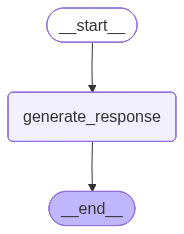

In [26]:
checkpoint=MemorySaver()
graph=StateGraph(ChatbotState)

graph.add_node('generate_response',generate_response)

graph.add_edge(START,'generate_response')
graph.add_edge('generate_response',END)

workflow=graph.compile(checkpointer=checkpoint)
workflow

In [27]:
initial_state={
    'messages':[HumanMessage(content="What is the capital of France?")]
}
result=workflow.invoke(initial_state)
print(result)

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [28]:
thread_id='1'
while True:
    user_message=input('Type your message: ')

    print(f"User: {user_message}")

    if user_message.strip().lower() in ['exit', 'quit','bye']:
        print("Exiting the chatbot. Goodbye!")
        break
    config ={'configurable': {'thread_id': thread_id}}
    response= workflow.invoke({'messages':[HumanMessage(content=user_message)]}, config=config)
    print('AI:',response['messages'][-1].content[0]['text'])

User: Hii my name is xyz
AI: Hi xyz! Nice to meet you. How can I help you today?
User: What is my name
AI: You just told me your name is **xyz**! 😊 How can I help you today?
User: bye
Exiting the chatbot. Goodbye!
